## Ejercicio 1: ¿Cuál es la frecuencia mínima de muestreo?

Dada la señal:

$$x(t) = \sin(6\pi t) + 0.5\cos(2\pi t)$$

1. Calcular la frecuencia máxima contenida en la señal.
2. Determinar la frecuencia mínima de muestreo según Nyquist.
3. Graficar la señal continua y su muestreo con $f_s = 10\,Hz$ y $f_s = 3\,Hz$.
4. Analizar el aliasing.

Aliasing: es un fenómeno que ocurre cuando una señal continua se muestrea a una frecuencia demasiado baja. Es decir, la señal reconstruida no representa correctamente la señal original debido a este fenómeno.

In [45]:
import numpy as np
import math as mth
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

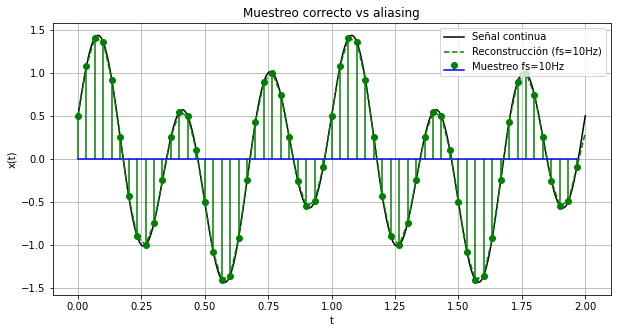

In [46]:

# señal continua
t = np.linspace(0, 2, 1000)
x = np.sin(6*np.pi*t) + 0.5*np.cos(2*np.pi*t)

# muestreo con fs = 10 Hz
fs1 = 30
t1 = np.arange(0, 2, 1/fs1)
x1 = np.sin(6*np.pi*t1) + 0.5*np.cos(2*np.pi*t1)
f_good = interp1d(t1, x1, kind='linear', fill_value="extrapolate")
x_good_interp = f_good(t)

# gráfica
plt.figure(figsize=(10,5))
plt.plot(t, x, label="Señal continua", color='black')

plt.stem(t1, x1, linefmt='g-', markerfmt='go', basefmt="b", label="Muestreo fs=10Hz")
plt.plot(t, x_good_interp, 'g--', label='Reconstrucción (fs=10Hz)')

plt.grid(True)
plt.title("Muestreo correcto vs aliasing")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend()

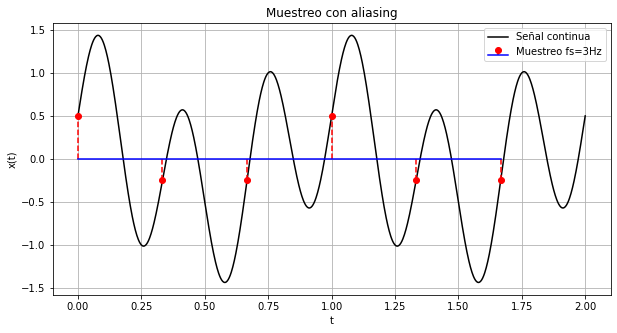

In [47]:
# señal continua
t = np.linspace(0, 2, 1000)
x = np.sin(6*np.pi*t) + 0.5*np.cos(2*np.pi*t)

# muestreo con fs = 3 Hz
fs2 = 3
t2 = np.arange(0, 2, 1/fs2)
x2 = np.sin(6*np.pi*t2) + 0.5*np.cos(2*np.pi*t2)

# gráfica
plt.figure(figsize=(10,5))
plt.plot(t, x, label="Señal continua", color='black')
plt.stem(t2, x2, linefmt='r--', markerfmt='ro', basefmt="b", label="Muestreo fs=3Hz")

plt.grid(True)
plt.title("Muestreo con aliasing")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend()

# Ejercicio 2: Reconstrucción vs aliasing

Dada la señal:

$$x(t) = \cos(8\pi t)$$

Se pide:
1. Graficar la señal continua.
2. Muestrarla con $f_s = 16\,Hz$ y $f_s = 6\,Hz$.
3. Reconstruir usando interpolación lineal.
4. Comparar los resultados y discutir aliasing.

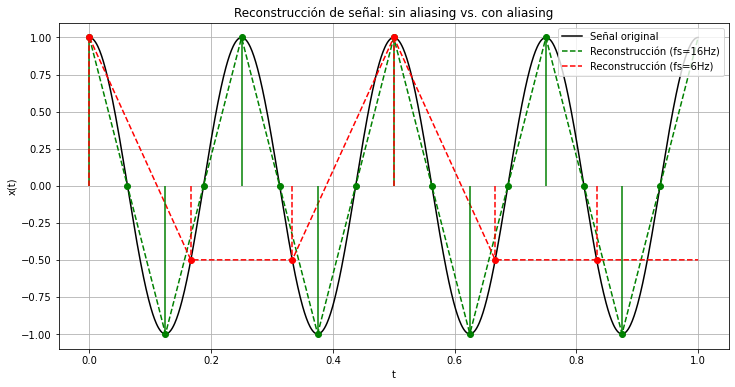

In [48]:
# señal continua
t_cont = np.linspace(0, 1, 1000)
x_cont = np.cos(8*np.pi*t_cont)

# muestreo bueno
fs_good = 16
t_good = np.arange(0, 1, 1/fs_good)
x_good = np.cos(8*np.pi*t_good)
f_good = interp1d(t_good, x_good, kind='linear', fill_value="extrapolate")
x_good_interp = f_good(t_cont)

# muestreo malo
fs_bad = 6
t_bad = np.arange(0, 1, 1/fs_bad)
x_bad = np.cos(8*np.pi*t_bad)
f_bad = interp1d(t_bad, x_bad, kind='linear', fill_value="extrapolate")
x_bad_interp = f_bad(t_cont)

# gráfica
plt.figure(figsize=(12, 6))
plt.plot(t_cont, x_cont, 'k', label='Señal original')
plt.plot(t_cont, x_good_interp, 'g--', label='Reconstrucción (fs=16Hz)')
plt.plot(t_cont, x_bad_interp, 'r--', label='Reconstrucción (fs=6Hz)')
plt.stem(t_good, x_good, linefmt='g-', markerfmt='go', basefmt=" ")
plt.stem(t_bad, x_bad, linefmt='r--', markerfmt='ro', basefmt=" ")
plt.legend()
plt.title("Reconstrucción de señal: sin aliasing vs. con aliasing")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
